# Decision Tree (stablo odluke)

***linkovi na filmice:***
- https://www.youtube.com/watch?v=_L39rN6gz7Y&t=18s
- https://www.youtube.com/watch?v=wpNl-JwwplA


In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.stats import linregress

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

base_path = '../../data/all_sorted'
classes = ['BIC', 'CAR', 'HEAVY', 'MC']

## Pretprocesiranje i ekstrakcija znacajki

Ovo je identican pipeline kao u glavnoj EDA analizi (notch filter za mrezni hum + high-pass,
pa isti prosireni set znacajki bez `peak_frequency`) - kopiran ovdje radi izravne usporedivosti
rezultata izmedju modela, bez ponovnog objasnjavanja EDA dijela (taj je vec napravljen).

In [2]:
def remove_mains_hum(y, sr, hum_freqs=(50, 100, 150, 200), Q=30):
    """Uski notch filter na mreznoj frekvenciji i njenim harmonicima. Q=30 znaci vrlo uzak
    filter - makne samo usku vrpcu oko svake frekvencije, ne dira okolni spektar."""
    y_filt = y.copy()
    for f0 in hum_freqs:
        if f0 >= sr / 2:
            continue
        b, a = signal.iirnotch(f0, Q, sr)
        y_filt = signal.filtfilt(b, a, y_filt)
    return y_filt


def highpass(y, sr, cutoff=15, order=4):
    """Blagi high-pass da uklonimo vrlo niske frekvencije koje nam ne trebaju, koje mogu biti
    samo sum."""
    sos = signal.butter(order, cutoff, btype='highpass', fs=sr, output='sos')
    return signal.sosfiltfilt(sos, y)


def preprocess(y, sr):
    y = remove_mains_hum(y, sr)
    y = highpass(y, sr)
    return y

In [3]:
LOW_BAND = (0, 300)
MID_BAND = (300, 2000)
HIGH_BAND = (2000, 11025)


def fft_psd(y, sr):
    window = np.hanning(len(y))
    y_win = y * window

    fft = np.fft.rfft(y_win)
    psd = np.abs(fft) ** 2

    freqs = np.fft.rfftfreq(len(y), 1 / sr)
    return freqs, psd


def band_energy_ratios(freqs, psd):
    total = psd.sum() + 1e-12

    def band_frac(lo, hi):
        mask = (freqs >= lo) & (freqs < hi)
        return psd[mask].sum() / total

    return band_frac(*LOW_BAND), band_frac(*MID_BAND), band_frac(*HIGH_BAND)


def spectral_slope(freqs, psd, f_min=20, f_max=4000):
    mask = (freqs >= f_min) & (freqs <= f_max) & (psd > 0)
    if mask.sum() < 2:
        return 0.0
    log_f = np.log10(freqs[mask])
    log_p = np.log10(psd[mask])
    slope, _, _, _, _ = linregress(log_f, log_p)
    return slope


def bandwidth_low_band(freqs, psd):
    lo, hi = LOW_BAND
    mask = (freqs >= lo) & (freqs < hi)
    f = freqs[mask]
    p = psd[mask]
    if p.sum() <= 0:
        return 0.0
    centroid = np.average(f, weights=p)
    return np.sqrt(np.average((f - centroid) ** 2, weights=p))


def extract_features(y, sr):
    freqs, psd = fft_psd(y, sr)

    rms = np.mean(librosa.feature.rms(y=y))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    low_e, mid_e, high_e = band_energy_ratios(freqs, psd)
    slope = spectral_slope(freqs, psd)
    bw_low = bandwidth_low_band(freqs, psd)

    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    flux = np.abs(np.diff(onset_env))

    flatness = librosa.feature.spectral_flatness(y=y)[0]

    y_harm, y_perc = librosa.effects.hpss(y)
    harm_energy = np.sum(y_harm ** 2)
    perc_energy = np.sum(y_perc ** 2)
    harmonic_ratio = harm_energy / (harm_energy + perc_energy + 1e-12)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=5)

    feats = {
        'rms': rms,
        'zcr': zcr,
        'spectral_centroid': centroid,
        'spectral_bandwidth': bandwidth,
        'spectral_rolloff': rolloff,
        'low_band_energy': low_e,
        'mid_band_energy': mid_e,
        'high_band_energy': high_e,
        'spectral_slope': slope,
        'bandwidth_low_band': bw_low,
        'flux_mean': np.mean(flux),
        'flux_std': np.std(flux),
        'spectral_flatness_mean': np.mean(flatness),
        'spectral_flatness_std': np.std(flatness),
        'harmonic_ratio': harmonic_ratio,
    }

    for i in range(5):
        feats[f'mfcc_{i}_mean'] = np.mean(mfcc[i])
        feats[f'mfcc_{i}_std'] = np.std(mfcc[i])

    return feats

In [8]:
CACHE_PATH = '../../data/features_cache/znacajke_cache.pkl'

if os.path.exists(CACHE_PATH):
    # Znacajke su vec izracunate i spremljene - samo ucitamo gotov DataFrame
    df = pd.read_pickle(CACHE_PATH)
    print(f"Znacajke ucitane iz cachea: {CACHE_PATH} ({len(df)} uzoraka)")
else:
    data = []

    for label in classes:
        folder = os.path.join(base_path, label)
        files = [f for f in os.listdir(folder) if f.endswith('.wav')]

        for i, file in enumerate(files):
            path = os.path.join(folder, file)

            if i % 10 == 0:
                print(f"   {label}: {i}/{len(files)} -> {file}")

            y, sr = librosa.load(path, sr=None)
            y = y[:sr * 2]  # CLIP_SECONDS = 2
            y = preprocess(y, sr)

            feats = extract_features(y, sr)
            feats['label'] = label
            data.append(feats)

    print(f"\nGotovo! Ukupno uzoraka: {len(data)}")

    df = pd.DataFrame(data)
    df = df[[c for c in df.columns if c != 'label'] + ['label']]

    df.to_pickle(CACHE_PATH)
    print(f"Znacajke spremljene u cache: {CACHE_PATH}")

print("\nBroj uzoraka po klasi (provjera balansa):")
print(df['label'].value_counts())

X = df.drop(columns=['label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

df.head()

Znacajke ucitane iz cachea: ../../data/features_cache/znacajke_cache.pkl (11391 uzoraka)

Broj uzoraka po klasi (provjera balansa):
label
CAR      9348
HEAVY    1190
MC        519
BIC       334
Name: count, dtype: int64


,rms,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,low_band_energy,mid_band_energy,high_band_energy,spectral_slope,bandwidth_low_band,...,mfcc_0_std,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,label
0,0.065307,0.019609,1826.503815,3078.726276,3590.425532,0.885687,0.101071,0.013052,-1.867504,45.903706,...,10.003626,178.775146,8.686232,-21.621541,5.821289,36.673271,4.580609,-1.047381,4.811483,BIC
1,0.035374,0.015698,2076.097549,4056.747926,4311.128657,0.971927,0.026018,0.001874,-2.311674,32.781818,...,22.649855,156.664657,11.681949,12.578587,7.050431,34.767883,6.372147,6.526522,8.544958,BIC
2,0.023371,0.036772,2588.184819,4263.899547,5891.040559,0.606855,0.378988,0.010833,-2.257224,65.991067,...,19.032952,167.932851,13.178547,2.001518,8.522644,37.542249,6.599697,-10.102805,7.831448,BIC
3,0.015145,0.041662,3539.687221,4993.381655,8676.861702,0.865271,0.112723,0.016721,-1.862074,42.518202,...,28.413603,140.353747,20.136714,-1.482174,10.328294,31.438115,6.909532,-8.179644,7.339408,BIC
4,0.005752,0.153959,4113.331616,4369.290481,9066.073803,0.322573,0.342152,0.329180,-1.000743,84.206649,...,13.254949,133.573605,16.001052,-39.154997,12.569525,36.705386,7.314667,-15.412616,6.875457,BIC


## 1. Teorijska podloga

### Sto je stablo odluke?

video za pomoc: https://www.youtube.com/watch?v=343ks0O3EkQ

Decision tree je model koji rekurzivno dijeli prostor znacajki na sve manje regije, birajuci u
svakom koraku onaj **prag jedne znacajke** koji najbolje razdvaja klase u tom cvoru. Rezultat je
hijerarhija if/else pravila - npr. "ako je `mfcc_3_mean` < X, idi lijevo, inace desno" - sve dok
listovi (leaf nodes) ne postanu (dovoljno) cisti, tj. sadrze prevladavajuce jednu klasu.

Algoritam koji `sklearn.tree.DecisionTreeClassifier` implementira je **CART** (Classification
and Regression Trees) - [**VIDJETI izvor1**]

CART u svakom cvoru bira split koji **maksimalno smanjuje necistocu** (impurity) potomaka.
Dvije standardne mjere necistoce za klasifikaciju (obje dostupne u sklearn-u):

- **Gini impurity**: $Gini = 1 - \sum_{k} p_k^2$, gdje je $p_k$ udio klase $k$ u cvoru.
  Mjeri vjerojatnost da bi nasumicno oznacen uzorak iz cvora bio pogresno klasificiran kad bi
  se oznacavao prema distribuciji klasa u tom cvoru.
- **Entropija** (informacijski dobitak): $H = -\sum_k p_k \log_2 p_k$, korijeni u teoriji
  informacija (Shannon) - split se bira tako da maksimizira smanjenje entropije (information
  gain) izmedju roditelja i potomaka. entropija --> razina kaoticnosti, nesigurnosti

U praksi Gini i entropija gotovo uvijek daju vrlo slicna stabla; Gini je default u sklearn-u
jer je racunski jeftiniji (nema logaritma).

### Prednosti

- **Interpretabilnost** - stablo se moze doslovno nacrtati i procitati kao skup pravila, sto je
  rijetkost medju modelima usporedive snage.
- Ne treba skaliranje/normalizacija znacajki (invarijantno na monotone transformacije).
- Prirodno hvata nelinearne granice i interakcije izmedju znacajki.

### Mane

- **Visoka varijanca / nestabilnost** - mala promjena u trening podacima moze dati bitno
  drugacije stablo (CART je poznat po ovome).
- Sklono **overfittingu** ako se ne ogranici dubina ili ne poreze (pruning) - stablo bez ogranicenja
  moze narasti dok svaki list ne sadrzi doslovno jedan trening uzorak, sto je savrseno pamcenje
  trening skupa, ne generalizacija.
- Greedy algoritam - split se bira lokalno optimalno u svakom cvoru, ne postoji garancija da je
  rezultat globalno optimalno stablo.

Upravo su mane (2) i (3) glavni razlog zasto Random Forest (vise stabala + agregacija) i
gradient boosting (stabla koja ispravljaju gresku prethodnih) gotovo uvijek nadmasuju pojedinacno
stablo.

## 2. Primjena na dataset

Koristimo `class_weight='balanced'` (isto kao kod RF-a ranije) zbog izrazene neravnoteze klasa
(CAR cca 82% uzoraka). Za usporedivost koristimo isti `train_test_split` (stratificiran,
`random_state=42`) kao u prethodnim notebookima.

Ogranicavamo `max_depth` na razumnu vrijednost (10) - bez ogranicenja, CART ce vjerojatno
overfittati (vidjeti teoriju iznad), pa usporedujemo train vs. test tocnost da to provjerimo
direktno, ne samo pretpostavimo.

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# cross validation - uzima cijeli set, dijeli puno pita i randomizira
clf = DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42)
clf.fit(X_train, y_train)

train_acc = clf.score(X_train, y_train)
test_acc = clf.score(X_test, y_test)
print(f"Train accuracy: {train_acc:.3f}")
print(f"Test accuracy:  {test_acc:.3f}")
print(f"Razlika (train - test): {train_acc - test_acc:.3f}  <-- sto veca, to vise overfitta")

Train accuracy: 0.813
Test accuracy:  0.726
Razlika (train - test): 0.087  <-- sto veca, to vise overfitta


              precision    recall  f1-score   support

         BIC       0.27      0.61      0.38        83
         CAR       0.95      0.76      0.84      2337
       HEAVY       0.36      0.67      0.47       298
          MC       0.18      0.35      0.24       130

    accuracy                           0.73      2848
   macro avg       0.44      0.60      0.48      2848
weighted avg       0.84      0.73      0.76      2848



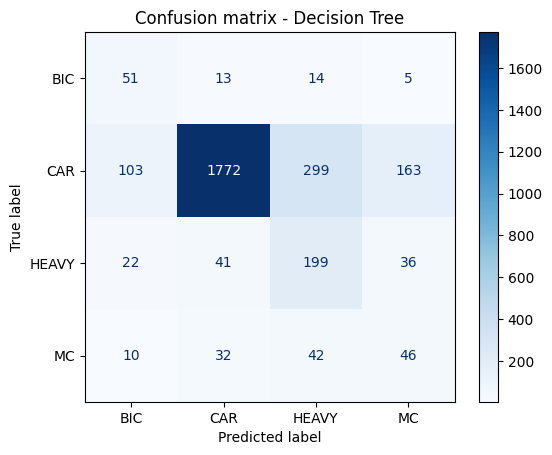

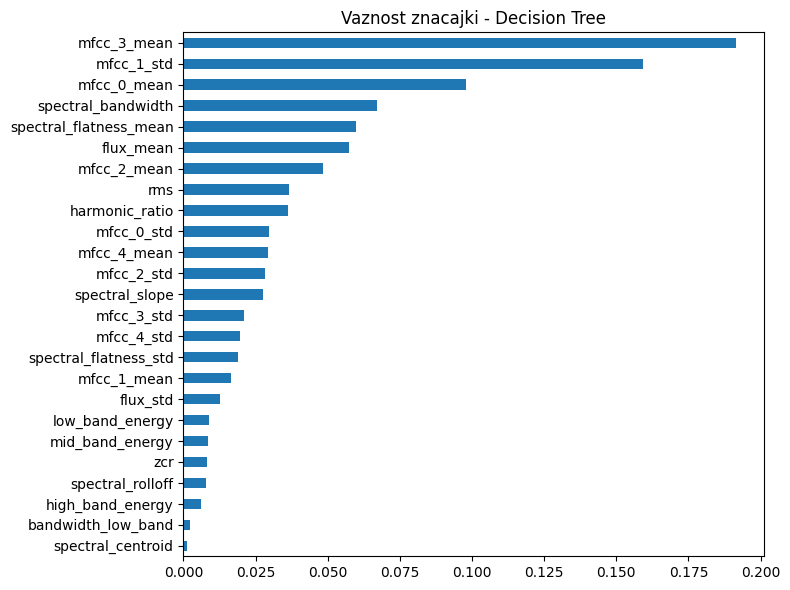

In [ ]:
# precision - od svih koje si oznacio kao bicikle koliko ih je stvarno bicikli
# recall - od svih stvarno bicikala koliko si ih oznacio kao bicikle
# F1-score - balans izmedju precisiona i recalla (harmonijska sredina)
# support - broj stvarnih instanci klase u testnom skupu
# accuracy - ukupna točnost modela (koliko je od svih instanci model ispravno klasificirao)
# macro avg - prosjek precision, recall i F1-score po klasama, bez uzimanja u obzir koliko instanci svaka klasa ima
# weighted avg - prosjek precision, recall i F1-score po klasama, uzimajući u obzir koliko instanci svaka klasa ima 

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion matrix - Decision Tree')
plt.show()

importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Vaznost znacajki - Decision Tree')
plt.tight_layout()
plt.show()

### Vizualni prikaz stabla (interpretabilnost)

Ovo je glavna prednost decision treeja nad RF/XGBoost - moze se doslovno pogledati logika
odlucivanja. Ogranicavamo prikaz na dubinu 3 (puno stablo dubine 10 bi bilo necitljivo), samo
kao ilustraciju kako izgleda prvih par splitova.

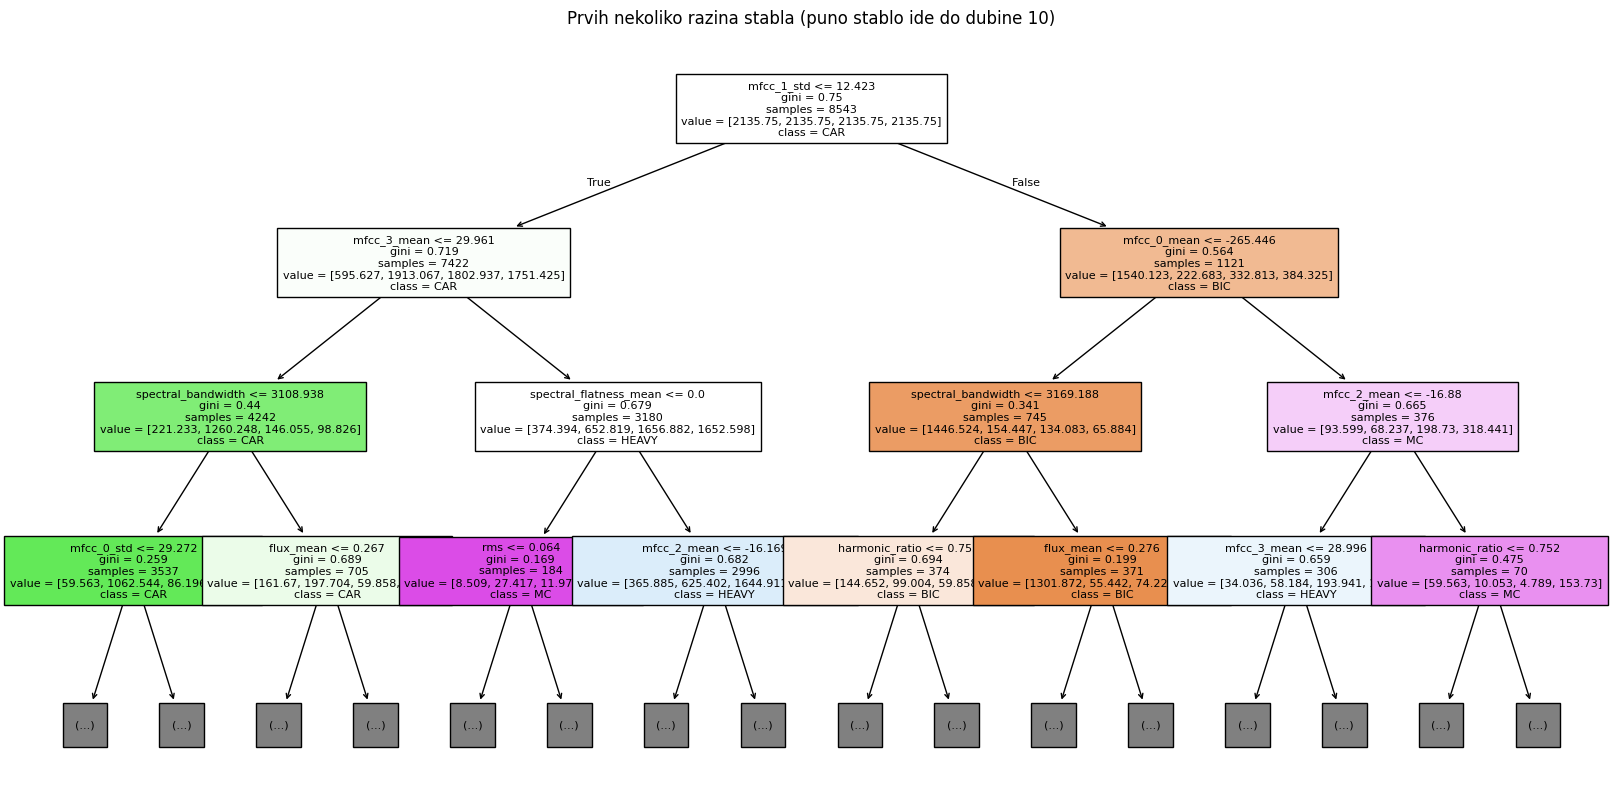

Stvarna dubina stabla: 10
Broj listova: 332


In [8]:
plt.figure(figsize=(20, 10))
plot_tree(clf, max_depth=3, feature_names=X.columns, class_names=clf.classes_,filled=True, fontsize=8)
plt.title('Prvih nekoliko razina stabla (puno stablo ide do dubine 10)')
plt.show()

print(f"Stvarna dubina stabla: {clf.get_depth()}")
print(f"Broj listova: {clf.get_n_leaves()}")

### Usporedba: sto se dogodi bez ogranicenja dubine?

Direktna demonstracija overfittinga opisanog u teoriji - stablo bez `max_depth` ograničenja
raste dok listovi ne postanu (skoro) cisti.

Bez ogranicenja dubine:
  Dubina: 33, broj listova: 1057
  Train accuracy: 1.000
  Test accuracy:  0.804

Ogranicena dubina (max_depth=10) radi usporedbe:
  Dubina: 10, broj listova: 332
  Train accuracy: 0.813
  Test accuracy:  0.726
Decision Tree (bez ogranicenja dubine):

              precision    recall  f1-score   support

         BIC       0.35      0.35      0.35        83
         CAR       0.89      0.90      0.89      2337
       HEAVY       0.41      0.41      0.41       298
          MC       0.36      0.33      0.34       130

    accuracy                           0.80      2848
   macro avg       0.50      0.50      0.50      2848
weighted avg       0.80      0.80      0.80      2848



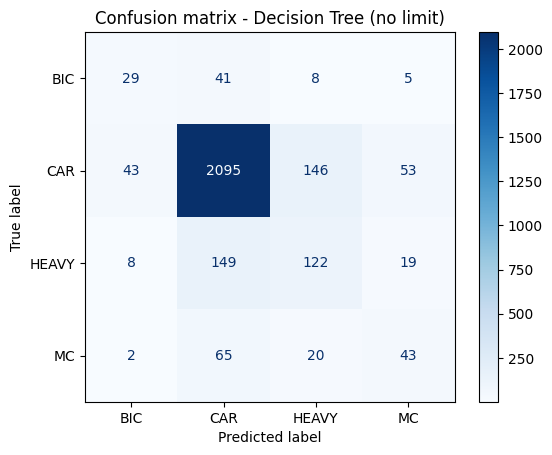

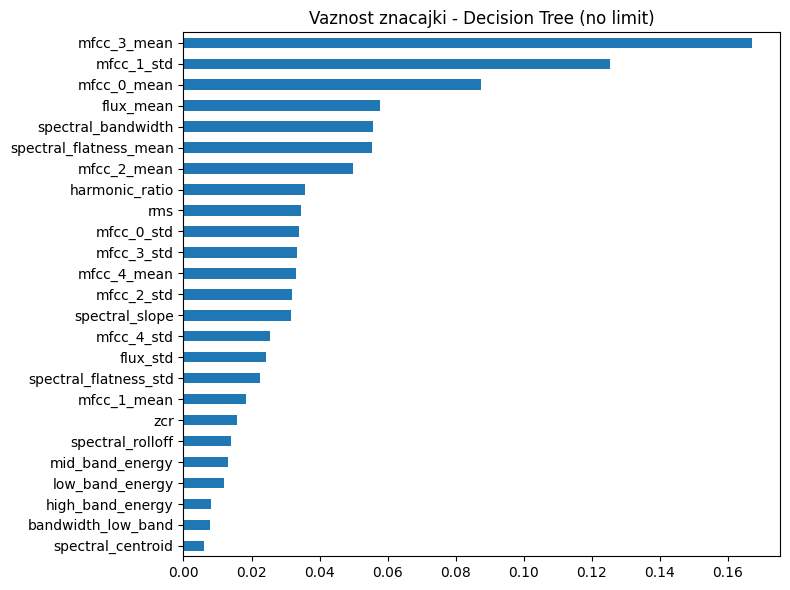

In [ ]:
clf_unbounded = DecisionTreeClassifier(class_weight='balanced', random_state=42)
clf_unbounded.fit(X_train, y_train)

print(f"Bez ogranicenja dubine:")
print(f"  Dubina: {clf_unbounded.get_depth()}, broj listova: {clf_unbounded.get_n_leaves()}")
print(f"  Train accuracy: {clf_unbounded.score(X_train, y_train):.3f}")
print(f"  Test accuracy:  {clf_unbounded.score(X_test, y_test):.3f}")
print()
print(f"Ogranicena dubina (max_depth=10) radi usporedbe:")
print(f"  Dubina: {clf.get_depth()}, broj listova: {clf.get_n_leaves()}")
print(f"  Train accuracy: {train_acc:.3f}")
print(f"  Test accuracy:  {test_acc:.3f}")


y_pred_unbounded = clf_unbounded.predict(X_test)

print("Decision Tree (bez ogranicenja dubine):\n")
print(classification_report(y_test, y_pred_unbounded))

cm_unbounded = confusion_matrix(y_test, y_pred_unbounded, labels=clf_unbounded.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_unbounded, display_labels=clf_unbounded.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion matrix - Decision Tree (no limit)')
plt.show()

importances_unbounded = pd.Series(clf_unbounded.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances_unbounded.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Vaznost znacajki - Decision Tree (no limit)')
plt.tight_layout()
plt.show()

# MSE koristiti na mjestu accuracya i log loss i MAE

## 3. Zakljucak

Accuracy je oko 70%, macro jest manji 48% ali to ima smisla jer nam je veliki bias na CAR klasu, weighted je zato veci 76%.

Vidi se da je potrebno ograniciti dubinu jer ako ga pustimo da ide dok ne dode do vecinski cisti listova onda se ocigledno overfitta.

Interpretabilan je, jako je zgodno za vidjeti stvarno stablo kako je odlucivalo.